<a href="https://colab.research.google.com/github/eliastche/PythonLabs/blob/main/Python_for_finance_Exam_FIRE_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Before you start
* Deactivate any generative AI assistance tool:
  * Go to Tools
  * Go to Settings
  * Go to AI Assistance
  * Tick the box "Hide generative AI features"

You will be penalized if you start the test with generative AI features enabled. Let me know if you need help.


# Exam duration : 2h30

# Part 1 : programming exercises (6 points)

### Exercise 1 (1 point)
* Write a function that checks if a number given in parameter is divisible by both 7 and 13, by only one of these numbers, or by none of them. The function has to print the result.

In [17]:
def modulus7or13(a):

  check7 = (a % 7 == 0)
  check13 = (a % 13 == 0)

  return print("Number", a, "\nIs divisbile by 7?", check7, "\nIs divisbile by 13?", check13)


modulus7or13(91)

Number 91 
Is divisbile by 7? True 
Is divisbile by 13? True


### Exercise 2 (2.5 points)
* Write a function that counts how many times a particular element (given as parameter) occurs in a list (given as parameter) using a loop and conditional statements. The function should return that number

In [21]:
def countelements(list, a):
  counter = 0
  for i in list:
    if i == a:
      counter += 1

  return counter

list1 = [1,2,5,3,2,1,2]

countelements(list1,5)

1

### Exercise 3 (2.5 points)

* Write a function that checks if a password entered by a user is identical to the password given as a parameter of the function. The user must be asked to re-enter a password until he enters the correct one.

In [23]:
def passwordcheck(password):
  check = False
  userpassword = input("Enter your password: ")

  while userpassword != password:
    userpassword = input("Wrong password, please try again: ")

  check = True
  return print("Password is correct!", check)


passwordcheck("Elias")


Enter your password: basj
Wrong password, please try again: elias
Wrong password, please try again: Elias
Password is correct! True


# Part 2 : Data analysis and manipulation (10 points)


### 1. Load some stocks information into a pandas DataFrame (1 point)
* Using the yfinance module, download the Google stocks (ticker 'GOOG') in a DataFrame

In [73]:
import yfinance as yf
import pandas as pd

google_stock = yf.download("GOOG")

#Flatten it
google_stock = google_stock.xs('GOOG', level=1, axis=1)


/tmp/ipython-input-657996917.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google_stock = yf.download("GOOG")
[*********************100%***********************]  1 of 1 completed


### 2. Data analysis (4 points)
First two questions : justify your answers by writing down and executing the code that helped you answer the question.

* a. What is the first date in that DataFrame ? (1 point)
* b. What is the last date in that DataFrame ? (1 point)
* c. Plot the Close column as a function of time using seaborn (1 points)
* d. Plot a histogram of the Volume column
(1 points)


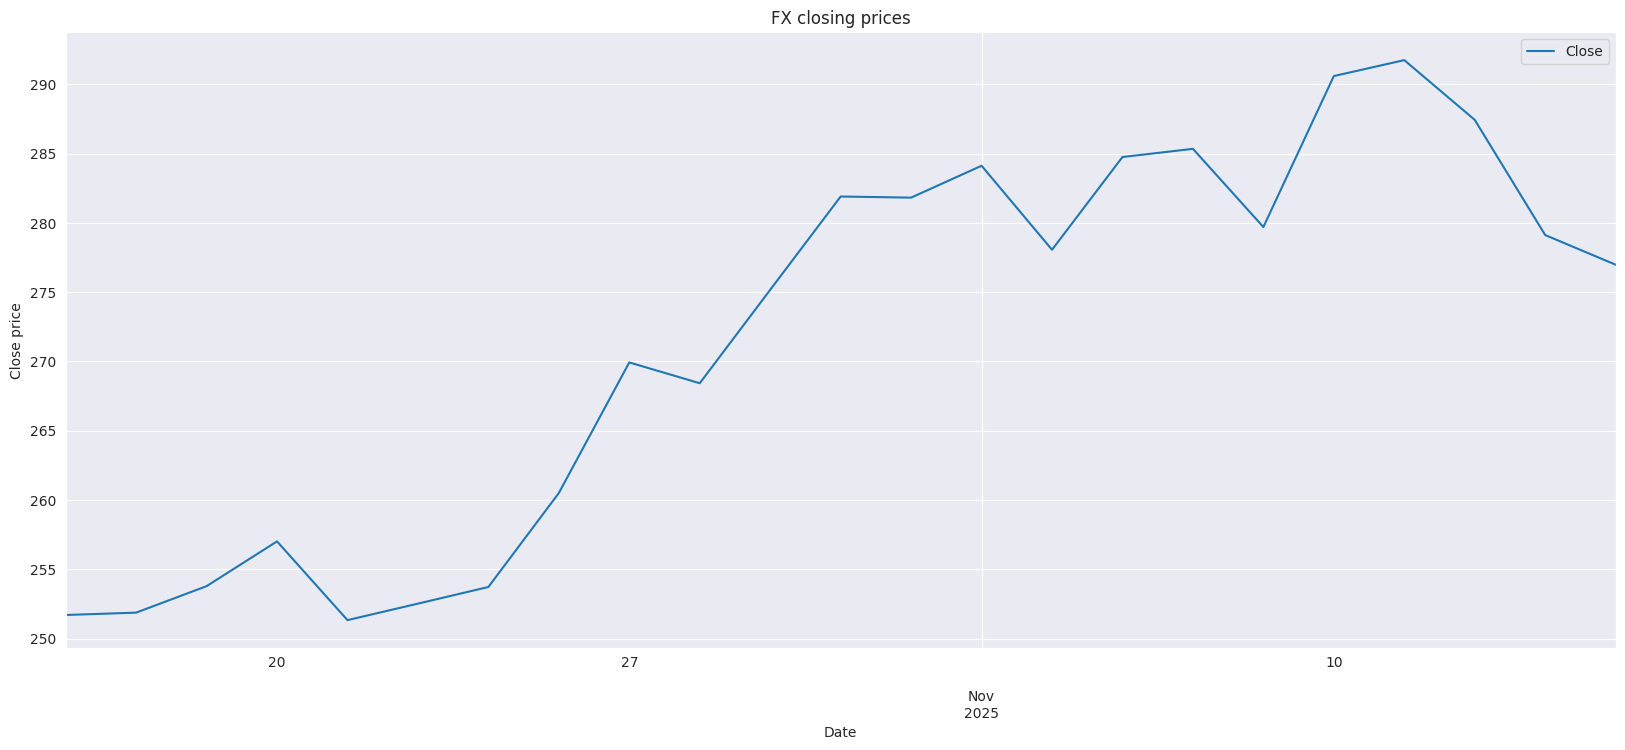

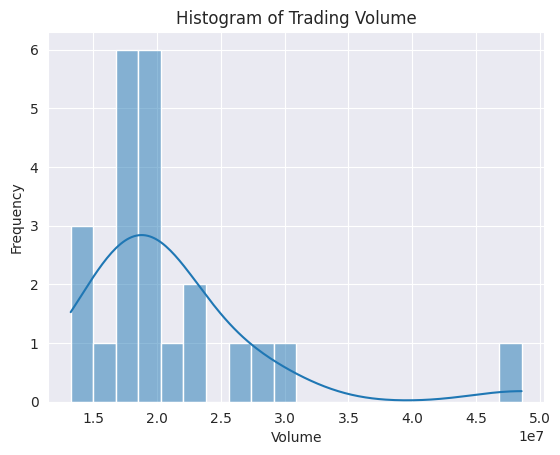

In [74]:
#Question a first date in that DataFrame
google_stock.head(1)
#First date is 2025-10-15

#Question b last date in that DataFrame
google_stock.tail(1)
#Last data is 2025-11-14

#Question c
import matplotlib.pyplot as plt
import seaborn as sns

google_stock.plot(y = 'Close', use_index=True, figsize=(20,8))

plt.title("FX closing prices")

plt.xlabel("Date")
plt.ylabel("Close price")
sns.set_style("darkgrid")

plt.show()

#Question d Plot a histogram of the Volume column
sns.histplot(google_stock["Volume"].dropna(), bins=20, kde=True)
plt.title("Histogram of Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

### 3. Data manipulation (5 points)
* **a. Daily return.** Add a column 'Daily Return' to the DataFrame. That column should contain the daily return value (i.e. the change in percentage from one day to the next). Compute these values by calculating a percentage change on the Close column. (1 point)
* **b. Moving average.** Add a 'Moving average' column to the DataFrame. Values in that column should be the moving average of the Close value for windows of 10 days. To do this, you can apply the rolling(...) and mean() methods on some column of the DataFrame. (2 points)
* **c. Price up.** Add a 'Price Up' column to the DataFrame. This column should contain a Boolean value: True if the Close value has increased from the current day to the next day, and False otherwise. You can use df[some_column].shift(-1) to get the value of a column at the line after. Use this function to check whether the next Close value is higher than the current one and store the result of this boolean expression in the new column. (2 points)

In [77]:
#A Daily returns
google_stock["Daily"] = google_stock["Close"].pct_change()

google_stock["Mov10"] = google_stock["Close"].rolling(window=10).mean()

def check1(stock):
  check = stock.shift(-1) > stock
  return check

google_stock["PriceUp"] = check1(google_stock["Close"]).fillna(False)


google_stock.tail()

Price,Close,High,Low,Open,Volume,Daily,Mov10,PriceUp
Date,,,,,,,,
2025-11-10,290.589996,291.459991,283.540009,285.265015,19508200,0.038935,280.988000,True
2025-11-11,291.739990,292.339996,287.880005,288.200012,14156700,0.003957,283.319000,False
2025-11-12,287.429993,292.359985,284.380005,292.084991,16998800,-0.014773,284.544998,False
2025-11-13,279.119995,283.510010,278.000000,282.984985,18060200,-0.028911,284.266998,False
2025-11-14,276.980011,279.149994,271.410004,271.894989,17953900,-0.007667,283.782999,False
